In [1]:
import scanpy as sc
import os
from datetime import datetime
import matplotlib.pyplot as plt

os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [3]:
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_extended_gbmap_hgnc.h5ad")

In [4]:
tica = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/02_TICA/TICAtlas.h5ad")


## Exploration of Categories in GBmap

In [5]:
print(adata.obs.columns.tolist())

# nach möglichen Spalten suchen, die Tumor/Healthy unterscheiden
for col in adata.obs.columns:
    if adata.obs[col].dtype.name in ["category", "object"]:
        unique_vals = adata.obs[col].unique()
        if len(unique_vals) < 50:  # nur überschaubare kategoriale Spalten anzeigen
            print(f"\n{col}: {unique_vals}")

['author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']

author: ['Yuan2018', 'Neftel2019', 'Wang2019', 'Wang2020', 'Zhao2020', ..., 'Ravi2022', 'LeBlanc2022', 'Ruiz2022', 'Jacob2020', 'Wang2021']
Length: 26
Categories (26, object): ['Abdelfattah2022', 'Bhaduri2020', 'Chen2021', 'Couturier2020', ..., 'Xie2021', 'Yu2020', 'Yuan2018', 'Zhao2020']

assay_ontology_term_id: ['EFO:0030002', 'EFO:0009899', 'EFO:0008931', 'EFO:0008953', 'EFO:070

In [5]:
adata.obs["celltype_original"].unique()

['unknown', 'Microglia', 'Tumor Associated Macrophage', 'Radial Glia', 'Glycolytic Progenitor', ..., 'BDM-like', 'Astrocyte', 'AC-like', 'Endothelial cells', 'MES-like']
Length: 94
Categories (93, object): ['AC-like', 'Astrocyte', 'B cells', 'B intermediate', ..., 'cDC2', 'dnT', 'gdT', 'pDC']

In [6]:
print(adata.var.columns.tolist())

# nach möglichen Spalten suchen, die Tumor/Healthy unterscheiden
for col in adata.var.columns:
    if adata.var[col].dtype.name in ["category", "object"]:
        unique_vals = adata.var[col].unique()
        if len(unique_vals) < 50:  # nur überschaubare kategoriale Spalten anzeigen
            print(f"\n{col}: {unique_vals}")

['feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type']

feature_types: ['Gene Expression']
Categories (1, object): ['Gene Expression']

genome: ['unknown']
Categories (1, object): ['unknown']

feature_reference: ['NCBITaxon:9606']
Categories (1, object): ['NCBITaxon:9606']

feature_biotype: ['gene']
Categories (1, object): ['gene']

feature_type: ['lncRNA', 'protein_coding', 'processed_pseudogene', 'transcribed_unitary_pseudogene', 'transcribed_processed_pseudogene', ..., 'TR_V_gene', 'translated_processed_pseudogene', 'scaRNA', 'IG_V_gene', 'TR_V_pseudogene']
Length: 25
Categories (25, object): ['IG_C_gene', 'IG_C_pseudogene', 'IG_V_gene', 'Mt_rRNA', ..., 'transcribed_unprocessed_pseudogene', 'translated_processed_pseudogene', 'unprocessed_pseudogene', 'vault_RNA']


In [ ]:
print(adata.shape)
print(adata.obs.columns.tolist())

(633710, 25987)
['author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']


In [10]:
print(repr(adata.var_names[0]))  # zeigt exakte Zeichen, inkl. mögliche Leerzeichen
print(any("CD3D" in str(x) for x in adata.var_names))

'ZNF470-DT'
True


In [9]:
print(adata.var.loc[adata.var.index.isin(test_genes)])

         feature_types   genome  highly_variable     means  dispersions  \
CD4    Gene Expression  unknown             True  0.317448     0.887052   
CD14   Gene Expression  unknown             True  0.916999     2.086850   
CD8A   Gene Expression  unknown             True  0.125975     1.298978   
CD3E   Gene Expression  unknown             True  0.161694     1.231017   
CD3D   Gene Expression  unknown             True  0.194937     1.604187   
NKG7   Gene Expression  unknown             True  0.258560     2.051416   
MS4A1  Gene Expression  unknown             True  0.013845     1.053063   

       dispersions_norm  highly_variable_nbatches  \
CD4            0.491429                        14   
CD14           1.908481                        24   
CD8A           1.977110                        22   
CD3E           1.853841                        21   
CD3D           2.646485                        23   
NKG7           3.342569                        22   
MS4A1          1.845510     

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os

adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_extended_gbmap_hgnc.h5ad")

marker_dict = {
    "CD4_CD8": ["CD3D", "CD3E", "CD4", "CD8A", "CD8B"],
    "B_cell": ["CD19", "MS4A1", "CD79A"],
    "Plasma_B": ["IGHG1", "MZB1", "JCHAIN", "CD38"],
    "NK": ["NKG7", "GNLY", "KLRD1"],
    "TAM-BDM": ["CD14", "CD163", "SPP1"],
    "TAM-MG": ["P2RY12", "CX3CR1", "TMEM119"],
    "DC": ["CD1C", "CLEC9A", "XCR1"],
    "Mono": ["CD14", "FCGR3A", "LYZ"],
    "Mast": ["TPSAB1", "CPA3", "KIT"],
    "Neutrophil": ["S100A8", "S100A9", "CSF3R"],
}


missing = [g for genes in marker_dict.values() for g in genes if g not in adata.var_names]
print(f"Fehlende Marker: {missing}")


sc.pl.dotplot(adata, marker_dict, groupby="annotation_level_3", use_raw=False, show=False)
plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/marker_dotplot_gbmap.pdf", bbox_inches="tight")
plt.close()

Fehlende Marker: []


## Exploration of TICAtlas

In [7]:
print(tica)
print(tica.obs.columns.tolist())
print(tica.var_names[:10])
print(tica.obs["lv1_annot"].value_counts())
print(tica.obs["lv2_annot"].value_counts())
print("X_umap" in tica.obsm)

AnnData object with n_obs × n_vars = 342758 × 106117
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'patient', 'percent.mt', 'gender', 'subtype', 'source', 'lv1_annot', 'lv2_annot', 'kmeans_cluster'
    var: '_index', 'features'
    obsm: 'X_umap'
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'patient', 'percent.mt', 'gender', 'subtype', 'source', 'lv1_annot', 'lv2_annot', 'kmeans_cluster']
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='object')
lv1_annot
CD8 cytotoxic               44849
CD4 naive-memory            32603
CD8 terminally exhausted    27857
CD4 effector memory         26130
T cells regulatory          25486
T cells naive               24344
B cells                     20704
CD4 recently activated      18080
TAMs C1QC                   17933
CD8 effector memory         13797
NK                          12141
T cells proliferative       11451
T helper cells              11420
Monocytes                   10995
Plasma B cells               8155
TAMs pr

In [10]:
print(tica.obs.columns.tolist())

# nach möglichen Spalten suchen, die Tumor/Healthy unterscheiden
for col in tica.obs.columns:
    if tica.obs[col].dtype.name in ["category", "object"]:
        unique_vals = tica.obs[col].unique()
        if len(unique_vals) < 50:  # nur überschaubare kategoriale Spalten anzeigen
            print(f"\n{col}: {unique_vals}")

['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'patient', 'percent.mt', 'gender', 'subtype', 'source', 'lv1_annot', 'lv2_annot', 'kmeans_cluster']

gender: ['female' 'male' 'unknown' 'NA']

subtype: ['BC' 'CRC' 'HCC' 'ICC' 'NSCLC' 'CM' 'EA' 'OC' 'PDAC' 'RCC' 'BCC' 'SCC'
 'UM']

source: ['breast' 'colorectal' 'liver2' 'liver1' 'lung2' 'lung1' 'multiple'
 'melanoma2' 'melanoma1' 'ovary' 'pancreas' 'skin' 'uveal melanoma']

lv1_annot: ['CD4 recently activated' 'CD4 naive-memory' 'Mast cells' 'TAMs C1QC'
 'B cells' 'CD8 cytotoxic' 'CD8 effector memory' 'mDC' 'Macrophages SPP1'
 'CD4 effector memory' 'cDC' 'NK' 'Monocytes' 'CD8 terminally exhausted'
 'CD4 transitional memory' 'Plasma B cells' 'T cells naive'
 'Macro. and mono. prolif.' 'T cells regulatory' 'pDC' 'T helper cells'
 'T cells proliferative' 'CD8 pre-exhausted' 'TAMs proinflamatory'
 'B cells proliferative']

lv2_annot: ['CD4 effector memory RA' 'CD4 memory stem cells' 'TAMs C1QC'
 'B cells unswitched memory' 'CD8 cytotoxic' 'NK' 

In [9]:
print(tica.var["features"][:10])

0    TSPAN6
1      DPM1
2     SCYL3
3       FGR
4       CFH
5     FUCA2
6      GCLC
7      NFYA
8    NIPAL3
9     LAS1L
Name: features, dtype: object


In [ ]:
tica.var_names = tica.var["features"].values

common_genes = set(tica.var_names) & set(adata.var_names)
print(f"Common genes in GBmap and TICA: {len(common_genes)}")

Common genes: 20672


[2026-08-19 12:59:03] Plotting UMAP of TICA colored by tissue


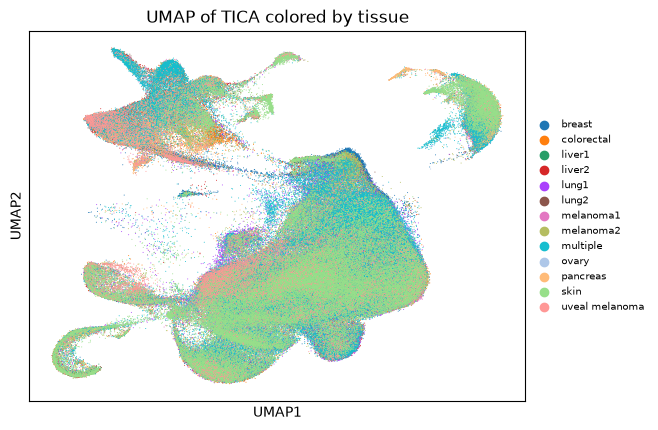

[2026-08-19 12:59:11] Saved


In [14]:
checkpoint("Plotting UMAP of TICA colored by tissue")
sc.pl.umap(tica, color="source", show=False, size=2, legend_fontsize=7, title="UMAP of TICA colored by tissue")
plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_01_TICA_umap_tissue.pdf", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
checkpoint("Saved")